<a href="https://colab.research.google.com/github/sabaripkumar/Azure-Scaleset---using-Terraform/blob/main/CET3052_Colab_PyTorch_NN_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch NN Basics

We will learn in depth about essential techniques to develop a neural network model for a prediction (or classification) task.

1.   a single layer of neuron
2.   activation functions
3.   loss functions
4.   optimizers
5.   evaluation metrics
6.   hyperparameters
7.   k-fold
8.   a real application to predict tweet sentiments



## Importing all libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

seed = 1337

torch.manual_seed(seed)
np.random.seed(seed)

You can turn on CUDA/GPU from "Connect - Change runtime type" option.

In [ ]:
from torch import cuda
torch.cuda.manual_seed_all(seed)

device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


## The Perceptron

One basic neural network layer has a computation graph like the below,

<img src="https://gamedevacademy.org/wp-content/uploads/2017/09/Single-Perceptron.png.webp" width=500>

If $X$ is the input matrix, $W$ is the weight matrix, $b$ is a random noise vector, $δ$ is the activation function, and $\hat{Y}$ is the output matrix. The basic NN layer can be formulated as,

$ \hat{Y} = δ(W \times X + b)$

* $W$ and $b$ are called as `parameters` of the model.
* $δ(W \times X + b)$ is called as `Neuron` or `Perceptron`.
* $\hat{Y}$ is the predicted value.
* $Y$ is the target value.




The below example creates a NN model consisting of one perceptron.

1. X has a dimension of `(batch_size, sequence_size, feature_size)`.
2. Y has a dimension of `(batch_size, output_dim)`, when `output_dim = 1`, y is a scaler number.

For example, a training batch consists of 3 sentences with each sentence having 2 words, and each words being represented by 5 features. That is,

`batch_size = 3,
sequence_size = 2,
feature_size = 5`

<img src="https://www.tensorflow.org/static/guide/images/tensor/index1.png">

When `output_dim=1`, it means output is a label (e.g., 0, 1, 2, 3) or a category (e.g. 1, 2, 3).

In [ ]:
class Perceptron(nn.Module):
    """
    A perceptron is one linear unit of neural network. For this example, we create one layer of neural network with just one perceptron.
    """

    def __init__(self, sequence_size, feature_size=1, batch_size = 1,
                 output_dim=1, cal_prob=True):
        """
        Args:
            sequence_size (int): input sequence size, e.g. number of words in
              one sentence.
            feature_size: size of the input features, e.g. number of values
              representing one word.
            batch_size: size of one training batch, e.g. number of sentences in
              one batch for training.
            output_dim (int): size of the output features, e.g. number of
              possible classes classified from one sentence.
            cal_prob (bool): whether to calculate the probability or not, e.g.
              return probabilities for classes.
        """
        super(Perceptron, self).__init__()
        self.cal_prob = cal_prob
        self.fc1 = nn.Linear(in_features=sequence_size,
                             out_features=output_dim,
                             bias=True)

    def forward(self, x_in):
        """The forward pass of the perceptron

        Args:
            x_in (torch.Tensor): an input data tensor. x_in.shape should be
              (batch_size, sequence_size, feature_size)
        Returns:
            The output tensor's shape should be (batch, sequence_size).
        """
        y = self.fc1(x_in)
        if self.cal_prob:
          y = torch.sigmoid(y)
        return y.squeeze()

## Activation Functions

Activiation are **nonlinear** functions used in the neural network to capture complex patterns in data. The following shows a few commonly used ones,

1. Sigmoid - $(0,1)$
 * $sigmoid(x) = \frac{1}{1 + e^{-x}}$

 * The output of the sigmoid function is always between 0 and 1. This makes it particularly useful for **binary classification problems**, where the output can be interpreted as a probability.

 * The sigmoid function has an S-shaped (sigmoid) curve, which smoothly transitions from 0 to 1. The midpoint of the curve is at $𝑥=0$, where $𝜎(0)=0.5$, $σ(0)=0.5$.


2. Hyperbolic Tangent Function, i.e., Tanh - $[-1, 1]$
  * $ \text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $
  * Like the sigmoid function, tanh has an S-shaped (sigmoid) curve but it is centered around $0$, which helps in balancing the outputs and making the optimization process more efficient.

3. Rectified Linear Unit, i.e., ReLU - $[0, ∞)$
  * $ReLU(x)=max(0,x)$
  * It is computationally simple and efficient because it only involves a threshold operation at zero. This makes it faster to compute compared to other activation functions like sigmoid or tanh.

4. Softmax - $[0, 1]$

  * Given a vector ${z} = [z_1, z_2, ..., z_n]$ of raw scores (logits), the softmax function is defined as, $softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}} $

  * It converts a vector of raw scores (logits) into a vector of probabilities, where each probability is between $0$ and $1$, and the sum of all probabilities is $1$, making it a general sigmoid function for **multi-class classification**.


### Classification Problems

* **Binary classification** is a type of classification task that involves predicting one of two possible classes or outcomes. It is the simplest form of classification problem where the output is either one class or the other.

* Typically, a neuron with a sigmoid activation function outputs a probability between 0 and 1. The class with the probability above a certain threshold (usually $0.5$) is chosen.

* **Multi-class classification** is a classification task that involves predicting one of three or more possible classes. Each instance is assigned to one, and only one, of the multiple classes.

* Typically, the output layer consists of multiple neurons (one for each class) with a softmax activation function. The softmax function converts the logits (raw scores) into probabilities for each class, and the class with the highest probability is chosen.

The figures below shows the hidden and output layer(s) for both classification problems.

<img src="https://thinkingneuron.com/wp-content/uploads/2020/10/How-to-use-ANN-for-classification-in-python.png"></img>

Reference:
[How to use Artificial Neural Networks for classification in python?](https://thinkingneuron.com/how-to-use-artificial-neural-networks-for-classification-in-python/).

### Visulization of Functions

#### Sigmoid

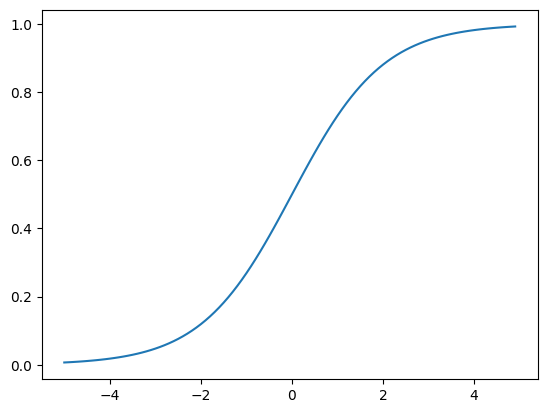

In [ ]:
x = torch.arange(-5., 5., 0.1)
y = torch.sigmoid(x)
plt.plot(x.numpy(), y.detach().numpy())
plt.show()

#### Tanh

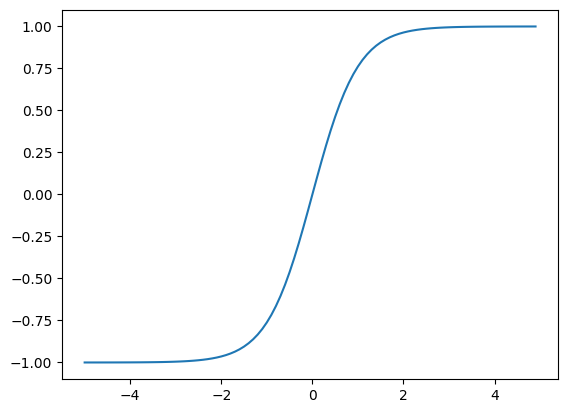

In [ ]:
x = torch.arange(-5., 5., 0.1)
y = torch.tanh(x)
plt.plot(x.numpy(), y.detach().numpy())
plt.show()

#### ReLU

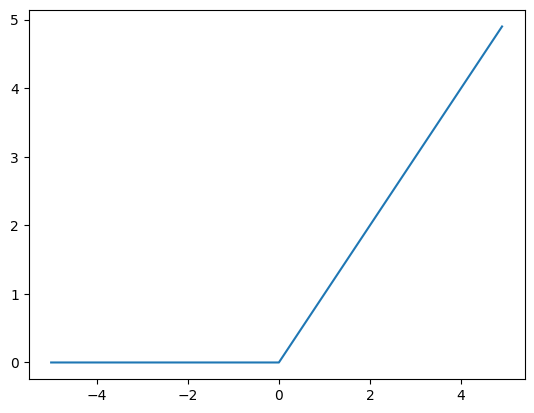

In [ ]:
x = torch.arange(-5., 5., 0.1)
y = nn.ReLU()(x)
plt.plot(x.numpy(), y.detach().numpy())
plt.show()

#### Parametric ReLU

The leak coefficient is a learned parameter, i.e., $f(x)=max(x, ax)$.

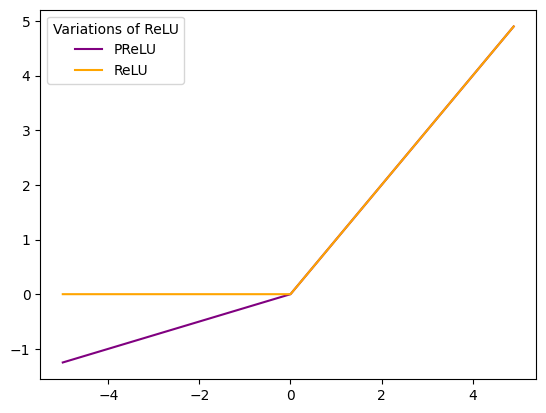

In [ ]:
prelu = nn.PReLU(num_parameters=1)
x = torch.arange(-5., 5., 0.1)
y1 = prelu(x)
y2 = nn.ReLU()(x)
plt.plot(x.numpy(), y1.detach().numpy(), color='purple', label='PReLU')
plt.plot(x.numpy(), y2.detach().numpy(), color='orange', label='ReLU')
plt.legend(loc='upper left',
           title='Variations of ReLU',
           fontsize='medium',
           frameon=True)
plt.show()

#### Softmax

In [ ]:
softmax = nn.Softmax(dim=1)
x_input = torch.randn(1, 3)
y_output = softmax(x_input)
print(x_input)
print(y_output)
# Validate probability sum to be 1.
print(torch.sum(y_output, dim=1))


tensor([[-2.0260, -2.0655, -1.2054]])
tensor([[0.2362, 0.2271, 0.5367]])
tensor([1.])


## Loss Functions

The loss function, also known as the **cost function** or **objective function**, quantifies the error between the predicted outputs of the model and the actual target values. It provides a measure of how well or poorly the model is performing. The primary goal during training is to minimize this loss function. Different types of loss functions are used depending on the nature of the problem (e.g., Mean Squared Error for regression tasks, Cross-Entropy Loss for classification tasks).

### Mean Squared Error (MSE)

Mean Squared Error (MSE) can be used for numerical outputs used in regression.

$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2$, where $\hat{y}_i$ is the output value, $y_i$ is the target value, and $n$ is the number of training data.



* Some variations are **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. The loss function depends on how you want to calculate the distance between two outputs - Euclidean distance or Manhattan distance.

In [ ]:
import torch.optim as optim

# Define the mean squared error loss
mse_loss = nn.MSELoss()

# Initialize outputs with requires_grad=True to compute gradients
outputs = torch.randn(3, 5, requires_grad=True)
targets = torch.randn(3, 5)

# Display initial outputs and targets
print(f'Initial outputs={outputs}')
print(f'Targets={targets}')

# Create an optimizer, passing it outputs to optimize.
# Optimizer computes the gradient.
optimizer = optim.SGD([outputs], lr=1.0)  # lr is the learning rate

# Compute the loss
loss = mse_loss(outputs, targets)
print(f'Initial loss={loss}')
print('---')

# Perform backpropagation to compute the gradients
loss.backward()
print(f'Gradients on outputs={outputs.grad}')

# Update the outputs based on the gradients
optimizer.step()

# Optionally, zero the gradients since PyTorch accumulates gradients
optimizer.zero_grad()

# Recompute the loss to see if it decreased
new_loss = mse_loss(outputs, targets)

# Display updated outputs and loss
print(f'Updated outputs={outputs}')
print(f'Updated loss={new_loss}')

# outputs at the current step - outputs.grad => outputs at the next step

Initial outputs=tensor([[-0.9122, -1.2502,  0.8032, -0.2071,  0.0544],
        [ 0.1378, -0.3889,  0.5133,  0.3319,  0.6300],
        [ 0.5815, -0.0282, -0.1744, -1.2221,  1.5787]], requires_grad=True)
Targets=tensor([[ 0.5397,  1.1634,  0.6947, -1.2307,  0.6871],
        [ 1.1841, -0.2909,  1.5433,  1.8641,  1.6099],
        [ 1.3526, -0.7395, -1.1731,  0.9226,  0.0033]])
Initial loss=1.603075385093689
---
Gradients on outputs=tensor([[-0.1936, -0.3218,  0.0145,  0.1365, -0.0844],
        [-0.1395, -0.0131, -0.1373, -0.2043, -0.1306],
        [-0.1028,  0.0948,  0.1332, -0.2860,  0.2100]])
Updated outputs=tensor([[-0.7186, -0.9284,  0.7888, -0.3436,  0.1388],
        [ 0.2773, -0.3758,  0.6507,  0.5362,  0.7607],
        [ 0.6843, -0.1230, -0.3076, -0.9362,  1.3686]], requires_grad=True)
Updated loss=1.2040876150131226


**Ex.** Can you apply the optimization 10 times to see how close outputs get to targets?

In [ ]:
# Define the mean squared error loss
mse_loss = nn.MSELoss()

# Initialize outputs with requires_grad=True to compute gradients
outputs = torch.randn(3, 5, requires_grad=True)
targets = torch.randn(3, 5)

# Display initial outputs and targets
print(f'Initial outputs={outputs}')
print(f'Targets={targets}')

# Create an optimizer, passing it the outputs as the parameters to optimize
optimizer = optim.SGD([outputs], lr=1.0)  # lr is the learning rate

for i in range(10):
  pass
  # Perform backpropagation to compute the gradients
  # Update the outputs based on the gradients
  # Recompute the loss to see if it decreased

Initial outputs=tensor([[ 0.6800, -0.8581,  0.3120, -0.8254, -0.0066],
        [-0.8289, -0.4105, -0.8437, -1.3370,  0.5897],
        [-0.2279,  0.5801,  1.1431, -0.7992,  1.5127]], requires_grad=True)
Targets=tensor([[ 1.0517,  0.2501,  1.5759,  0.6495,  0.9631],
        [ 1.0905, -0.4931, -0.9682, -0.1791,  0.2050],
        [-0.7801, -1.0036,  0.0850,  1.0277, -0.3999]])


### Cross-Entropy Loss

For categorical targets, the common loss function is **cross-entropy loss**. Entropy is from information theory and it computes difference between class's probabilities.

For example, for a binary classification, the cross-entroy between outputs and targets is,

$H(y, \hat{y}) = - \frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{M} y_{ic} \cdot \log(\hat{y}_{ic})$

Where:
- $N$ is the number of samples or instances.
- $M$ is the number of possible classes.
- $y_{ic}$ is a binary indicator of whether class label $(c)$ is the correct classification for observation $i$.
- $\hat{y}_{ic}$ is the predicted probability that observation $i$ is of class $c$.

In [ ]:
# Define the cross-entropy loss
ce_loss = nn.CrossEntropyLoss()

# Initialize outputs with requires_grad=True to compute gradients
batch_size = 3
output_dim = 5 # output could be one of five labels [0, 1, 2, 3, 4].

# torch.randn(3, 5) produces a 2-dimensional tensor (or matrix) with 3 rows and
# 5 columns. Each element in the tensor is a floating-point number sampled from
# a starndard normal distribution.
outputs = torch.randn(batch_size, output_dim, requires_grad=True)
targets = torch.tensor([1, 0, 3], dtype=torch.int64)

# Print initial outputs
print(f'Initial outputs:  {outputs}')
print(f'Targets:          {targets}')

# Create an optimizer, passing it the outputs as the parameters to optimize
optimizer = optim.SGD([outputs], lr=1.0)  # Adjust lr according to the sensitivity of your outputs

# Compute the loss
loss = ce_loss(outputs, targets)
print(f'Initial loss:     {loss.item()}')
print('---\n')

# Perform backpropagation to compute the gradients
loss.backward()

# Check the gradients on the outputs
print('Gradients on outputs:')
print(outputs.grad)
print('---')

# Update the outputs based on the gradients
optimizer.step()

# Zero the gradients to prevent them from accumulating
optimizer.zero_grad()

# Recompute the loss to see if it decreased
new_outputs = outputs.detach()  # Detach outputs from the graph to prevent further gradient tracking
new_loss = ce_loss(new_outputs, targets)
print('Updated outputs:')
print(new_outputs)
print(f'Updated loss: {new_loss.item()}')


Initial outputs:  tensor([[ 0.8997,  0.2513,  0.0527,  2.4278, -1.3424],
        [ 1.9883,  0.2066, -0.1502,  0.6722, -1.1737],
        [-1.4611, -0.5440,  0.1602, -0.5453,  0.0712]], requires_grad=True)
Targets:          tensor([1, 0, 3])
Initial loss:     1.6169015169143677
---

Gradients on outputs:
tensor([[ 0.0500, -0.3072,  0.0214,  0.2305,  0.0053],
        [-0.1246,  0.0351,  0.0246,  0.0560,  0.0088],
        [ 0.0212,  0.0532,  0.1075, -0.2802,  0.0983]])
---
Updated outputs:
tensor([[ 0.8497,  0.5585,  0.0313,  2.1974, -1.3477],
        [ 2.1128,  0.1715, -0.1748,  0.6162, -1.1825],
        [-1.4824, -0.5972,  0.0527, -0.2650, -0.0272]])
Updated loss: 1.351631760597229


In [ ]:
print(f'''The improvement of loss is:
  {np.round((1.2382627725601196 - 1.057889461517334)/1.2382627725601196, 3) * 100}%''')

The improvement of loss is: 
  14.6%


#### Binary Cross-Entropy

Binary Cross-Entropy, also known as log loss, is a loss function commonly used in binary classification tasks. It measures the performance of a model whose output is a probability value between 0 and 1. Binary cross-entropy loss compares each predicted probability to the actual class output, which can be either 0 or 1.

### Mathematical Definition:
Binary Cross-Entropy loss is defined mathematically for a set of predictions and actual outcomes as follows:
$$
L = -\frac{1}{N} \sum_{i=1}^N [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]
$$

Where:
- $N$ is the number of samples.
- $y_i$ is the actual label of the ith sample, which should be either 0 or 1.
- $p_i$ is the predicted probability of the ith sample being in class 1.
- $log$ is the natural logarithm.

Binary Cross-Entropy is a fundamental loss function for binary classification.

In [ ]:
bce_loss = nn.BCELoss()
softmax = nn.Softmax()

'''Create a tensor with random values drawn from a standard normal distribution
 (mean of 0 and standard deviation of 1).
  4, 1: Specifies the shape of the tensor.
  requires_grad=True: Keep track of all operations on the tensor so that it can
    compute gradients during backpropagation. This is useful for optimizing
    neural network weights using gradient descent or other optimization
    algorithms.
'''
outputs = torch.randn(4, 1, requires_grad=True)
print(f'outputs={outputs}\n')
probabilities = softmax(outputs)
print(f'probabilities={probabilities}\n')

targets = torch.tensor([1, 0, 1, 0], dtype=torch.float32).view(4, 1)
print(f'targets={targets}\n')

loss = bce_loss(probabilities, targets)

# Perform backpropagation to compute the gradients
# loss.?

# Check the gradients on the outputs
print('Gradients on outputs:')
print(outputs.grad)
print('---')

# Update the outputs based on the gradients
# optimizer.?

# Zero the gradients to prevent them from accumulating
# optimizer.?

# Recompute the loss to see if it decreased
new_outputs = outputs.detach()  # Detach outputs from the graph to prevent further gradient tracking
new_loss = ce_loss(new_outputs, targets)
print('Updated outputs:')
print(new_outputs)
print(f'Updated loss: {new_loss.item()}')

outputs=tensor([[ 0.7466],
        [-0.8654],
        [-0.2968],
        [-0.3842]], requires_grad=True)

probabilities=tensor([[0.6784],
        [0.2962],
        [0.4263],
        [0.4051]], grad_fn=<SigmoidBackward0>)

targets=tensor([[1.],
        [0.],
        [1.],
        [0.]])

Gradients on outputs:
None
---
Updated outputs:
tensor([[ 0.7466],
        [-0.8654],
        [-0.2968],
        [-0.3842]])
Updated loss: -0.0


## Optimizer

The optimizer is an algorithm that adjusts the model parameters (weights) to minimize the loss function. It updates the parameters based on the computed gradients from **backpropagation**. The optimizer determines the **direction** and **magnitude** of the changes to the parameters, helping the model converge to a **minimum loss**.

* **Learning Rate** controls the size of the gradient updates taken during the optimization process. A smaller learning rate results in smoother and more stable updates but may require more iterations to converge. Conversely, a larger learning rate can speed up convergence but risks missing the minimum and potentially leading to instability or divergence. For example, the equation below shows an abstract representation of parameter updates,

  $$w_{new} = w_{old} - \alpha \cdot \nabla_{w} Loss(\theta)$$

  - **Small Learning Rate**: where $\alpha$ is a small learning rate,$w$ is the parameter, and $\nabla_{w} Loss(w)$ is the gradient of the loss function with respect to the parameters.
    
  - **Large Learning Rate**: where $\alpha$ is a large learning rate, potentially causing large, unstable updates.

### Popular Optimizers

* **SGD (Stochastic Gradient Descent)** updates parameters using the gradient of the loss with respect to the parameters.

* **Adam (Adaptive Moment Estimation)** combines the first gradient (mean) and the second moment (variance) of the loss with respect to the parameters.

  Imagine you’re taking steps down the hill. Adam keeps track of two things for each step you take
  * The direction you’re moving (**mean**): This tells you which way is downhill.
  * How big your steps are (**variance**): This tells you how long or short your steps should be.
  * Learning Rate: This controls how big your steps should be.
    * If the target is very close (a steep hill), smaller learning rate creates small steps so you don't miss it.
    * If the target is far away (a gentle slope), bigger learning rate creates bigger steps to reach faster.

  * In practice, **Adam** is often used because it has a few advantages over the other optimizers,

    * Adaptivity: The algorithm adapts the learning rates of all model parameters by computing individual adaptive learning rates for different parameters.
    * Robustness: It works well for large datasets and high-dimensional parameter spaces.
    * Less Need for Hyperparameter Tuning: Default settings for the hyperparameters often work well.

The below image shows a steep slope and close target. <img src="https://statusneo.com/wp-content/uploads/2023/09/Credit-Medium.png" width=200 height=250> </img>

Reference:
https://statusneo.com/adam-efficient-deep-learning-optimization/

#### Weight Decay

`weight_decay` refers to the L2 regularization technique. L2 regularization is a method used to prevent overfitting by penalizing **large weights** in the model. In the Adam implementation, it can be used as below,

$ w = w - λ ⋅ L_{2}(w) - α⋅Δ(w)$

where:
- $ w $ is the parameter or weights in terms of neural network function.
- $ \lambda $ is the weight decay coefficient (regularization strength).
- $L_{2}$ is the L2 norm of weights.

Note:

The L2 norm of a matrix, is the magnitude of the matrix. It is calculated as the square root of the sum of the absolute squares of its elements. Given a matrix $ \mathbf{W} $ with elements $ w_{ij} $, the L2 norm $ \|\mathbf{W}\|_2 $ is defined as:

$$ \|\mathbf{W}\|_2 = \sqrt{\sum_{i,j} w_{ij}^2} $$

In [ ]:
import torch.optim as optim

In [ ]:
model = Perceptron(sequence_size=10)

# Define the loss function
loss_fn = nn.MSELoss()

# Define the optimizer with learning rate
optimizer = optim.Adam(model.parameters(),
                       lr=0.001,
                       betas=(0.9, 0.999),
                       weight_decay=1e-5)

epochs = 20

# Example training loop
for epoch in range(epochs):
    model.train()

    # Dummy input and target tensors
    inputs = torch.randn(32, 10)
    targets = torch.randn(32)

    # Forward pass
    outputs = model(inputs)
    loss = loss_fn(outputs, targets)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [1/20], Loss: 1.6593
Epoch [2/20], Loss: 1.3107
Epoch [3/20], Loss: 1.0040
Epoch [4/20], Loss: 0.9609
Epoch [5/20], Loss: 1.3532
Epoch [6/20], Loss: 0.9278
Epoch [7/20], Loss: 1.1007
Epoch [8/20], Loss: 0.9295
Epoch [9/20], Loss: 1.5723
Epoch [10/20], Loss: 0.9081
Epoch [11/20], Loss: 1.2015
Epoch [12/20], Loss: 1.4808
Epoch [13/20], Loss: 1.8825
Epoch [14/20], Loss: 1.4644
Epoch [15/20], Loss: 1.5897
Epoch [16/20], Loss: 1.5095
Epoch [17/20], Loss: 1.2368
Epoch [18/20], Loss: 0.6305
Epoch [19/20], Loss: 1.5224
Epoch [20/20], Loss: 1.4123


# Classification Framework

Here introduces a simple code skeleton to use Perceptron for classification problems.

* Major Hyperparameters:
  * epochs - how many times the full traning dataset will be seen by the model, e.g., 5.
  * batches - how many data samples will be used to update parameters at once, e.g., 10, means 10 samples per batch.
  * sequence size, e.g., 5 = means 5 features for one data sample.
  * lr - learning rate, e.g., 0.001, 0.0001.
  * weight_decay - L2 regulation strength, e.g., 1e-4.

  Other hyperparameters use default values.

In [ ]:
# Hyperparameters
n_epochs = 5
batch_size = 10
sequence_size = 20
lr = 0.0001
training_size = 700
validation_size = 300
testing_size = 250
n_batches = int(training_size / batch_size) # 70

# Prediction model uses one neuron or Perceptron
model = Perceptron(sequence_size=sequence_size, cal_prob=True)
# Loss function uses Binary Cross Entropy, so outputs could be 0 or 1
loss_fn = nn.BCELoss()
# Gradient is calculated by Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

### Training Code Skeleton

In [ ]:
for epoch in range(n_epochs):
    print(f'epoch={epoch}')
    epoch_loss = 0
    epoch_accuracy = 0
    for batch in range(n_batches):
        # Generate fake data for the batch.
        x = torch.randn(batch_size, sequence_size)
        y_target = torch.rand(batch_size,)
        #print(y_target)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass: compute predicted y by passing x to the model.
        y_pred = model(x)
        #print(f'y_pred.shape={y_pred.shape}')
        #print(f'y_pred={y_pred}')

        # Compute and print loss.
        loss = loss_fn(y_pred, y_target)

        # Propagate the loss value backward.
        loss.backward()

        # Trigger the optimizer to update once.
        optimizer.step()

        y_pred_labels = (y_pred > 0.5).int()
        y_target_labels = (y_target > 0.5).int()
        accuracy = (y_pred_labels == y_target_labels).float().mean()


        #if batch % 10 == 0:
        #  print(f'Epoch: {epoch}, Batch: {batch}, Loss: {loss.item()}')
        #  print(f'Epoch: {epoch}, Batch: {batch}, Accuracy: {accuracy.item()}')

        epoch_loss += loss
        epoch_accuracy += accuracy

    epoch_loss /= n_batches
    print(f"Epoch average loss: {epoch_loss}")
    print(f"Epoch average accuracy: {epoch_accuracy}")

epoch=0
Epoch average loss: 0.7310498952865601
Epoch average accuracy: 36.499996185302734
epoch=1
Epoch average loss: 0.7375167012214661
Epoch average accuracy: 35.60000228881836
epoch=2
Epoch average loss: 0.726881206035614
Epoch average accuracy: 35.400001525878906
epoch=3
Epoch average loss: 0.7366772294044495
Epoch average accuracy: 33.79999923706055
epoch=4
Epoch average loss: 0.7390019297599792
Epoch average accuracy: 34.89999771118164


# A Real Case Study - Tweet Sentiment Classification

Given a set of tweet data, each of which contains 3 fields: `id`, `tweet` and `sentiment`, train the dataset and predict sentiment for any new tweet data. The described task has a few steps:

1. **Loading Data**: load training dataset from: <a href="https://figshare.com/articles/dataset/smile_annotations_final_csv/3187909/2">SMILE Twitter Emotion dataset</a>. The dataset contains 3,085 tweets, that mentioned *British museums*, and were posted between May 2013 and June 2015. The dataset was created for the purpose of classifying sentiments expressed on Twitter towards arts and cultural experiences in museums.

2. **Tweet Vectorization**: create input features for each training tweet data by using `torch.nn.Embedding` to vectorize tweet text into a vector of numerical numbers.

3. **Target Value**: create a target value for each training tweet data by categorizing its sentiment. For example, `[0-anger, 1-disgust, 2-happiness, 3-surprise 4-sadness]`.

4. Decide **Loss and Optimization** functions: use cross-entropy as the loss function and Adam as the optimizer.

  For example, given a tweet `Bursting with pride after our South Asia Gallery was named Best Permanent Exhibition at last night's @MandHShow Awards.` and its sentiment label `happy`.

  Step 2 will vectorize the tweet into an embedding matrix $𝐗$. The dimension of matrix is `[batch_size, sequence_size, embedding_vector_length]`.
  
  Step 3 will transform the sentiment label - `happy` to an integer, i.e., $y=2$.
  
  Step 4 will chose Cross-Entropy loss function and Adam Optimizer.
  
  Our goal is to train parameters matrix $𝐖$ for a neural network model - Perceptron, that is,
      
  Given input feature matrix $𝐗$ and target output vector $y$, train matrix $𝐖$, using model $f_{α}(𝐖, 𝐗)=y$, where $α$ is the hyperparameter.

#### Excercises

Qn1. why loss function uses Cross-Entropy, other than MSE (Mean Squared Error)?

Qn2. what are possible hyperparameters meant by $α$?

## Tweet Text Vectorization

Tweet texts are required to be transformed into numerical values so can be used for neural network functions. For this purporse, a few steps are required,

1. Tokenzie texts into individual word units. See a picture example below,

<img src="https://mlspring.files.wordpress.com/2022/11/we_love_nlp.png?w=792" width=300></img>

2. Tokens are then transformed to embedding vectors by using a pre-trained mapping. An embedding vector means a vector of numerical numbers, which is generated from pre-training some language models on a large and classic text corpus. Embedding vectors are usually stored in a dictionary like data structure (a huge list of key-value pairs) with one word as one key, and a list of float values as its value. See a pre-trained mapping example of $8$ embedding vectors, representing $8$ English words, each of which is represented by a vector of $7$ floating values.

<img src="https://storage.googleapis.com/coderzcolumn/static/tutorials/artificial_intelligence/word_embeddings.jpg"></img>

## Loading Data

In [ ]:
!wget https://github.com/ruslanmv/Deep-Learning-using-BERT/raw/main/Data/smile-annotations-final.csv

--2024-07-27 03:47:00--  https://github.com/ruslanmv/Deep-Learning-using-BERT/raw/main/Data/smile-annotations-final.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ruslanmv/Deep-Learning-using-BERT/main/Data/smile-annotations-final.csv [following]
--2024-07-27 03:47:01--  https://raw.githubusercontent.com/ruslanmv/Deep-Learning-using-BERT/main/Data/smile-annotations-final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 429669 (420K) [text/plain]
Saving to: ‘smile-annotations-final.csv.2’

smile-annotations-f 100%[===================>] 419.60K  --.-KB/s    in 0.004s  

2024-07-27 03:4

In [ ]:
import pandas as pd
df = pd.read_csv('smile-annotations-final.csv',
                 names =['id', 'tweet', 'category'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3085 entries, 0 to 3084
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3085 non-null   int64 
 1   tweet     3085 non-null   object
 2   category  3085 non-null   object
dtypes: int64(1), object(2)
memory usage: 72.4+ KB


### Cleaning Data

In [ ]:
df['tweet'] = df['tweet'].astype('string')
df['category'] = df['category'].astype('string')

In [ ]:
df.category.value_counts()

category
nocode               1572
happy                1137
not-relevant          214
angry                  57
surprise               35
sad                    32
happy|surprise         11
happy|sad               9
disgust|angry           7
disgust                 6
sad|disgust             2
sad|angry               2
sad|disgust|angry       1
Name: count, dtype: Int64

In [ ]:
df.loc[df['category'].str.contains('sad|angry|surprise|disgust'), 'category'] = 'sad'
df_sad = df[df['category'].str.contains('sad', na=False)]

df_happy = df[df['category'].str.match(r'^happy$', na=False)]
df_happy = df_happy.sample(frac=0.16).reset_index(drop=True)

df_not_relevant = df[df['category'].str.match(r'^not-relevant$', na=False)]
df_not_relevant = df_not_relevant.sample(frac=0.75).reset_index(drop=True)

combined_df = pd.concat([df_sad, df_happy, df_not_relevant], ignore_index=True)
sample_df = combined_df.sample(frac=1).reset_index(drop=True)

total = sample_df.category.value_counts()

In [ ]:
print(f"Total number of tweets: {np.sum(total)}")
print(f"Distribution of sampled tweets per {total}\n")
print(f"Total number of sampled tweets: {np.sum(total)}")

Total number of tweets: 504
Distribution of sampled tweets per category
happy           182
sad             162
not-relevant    160
Name: count, dtype: Int64

Total number of sampled tweets: 504


### Target Values

In [ ]:
sample_df['target'] = sample_df['category'].astype('category').cat.codes

In [ ]:
dist = sample_df.target.value_counts()
print(f"Distribution of sampled tweets per {dist}\n")
print(np.sum(dist))

Distribution of sampled tweets per target
0    182
2    162
1    160
Name: count, dtype: int64

504


## Preparing Traning and Testing Datasets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing datasets.
train_df, test_df = train_test_split(sample_df,
                                     test_size=0.25,
                                     random_state=42,
                                     stratify=sample_df.target.values)

In [ ]:
train_df.info()
test_df.info()

print(train_df.target.value_counts())
print(train_df.category.value_counts())
print(np.sum(train_df.target.value_counts()))
print("---")
print(test_df.target.value_counts())
print(test_df.category.value_counts())
print(np.sum(test_df.target.value_counts()))

<class 'pandas.core.frame.DataFrame'>
Index: 378 entries, 389 to 352
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        378 non-null    int64 
 1   tweet     378 non-null    string
 2   category  378 non-null    string
 3   target    378 non-null    int8  
dtypes: int64(1), int8(1), string(2)
memory usage: 12.2 KB
<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 54 to 376
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        126 non-null    int64 
 1   tweet     126 non-null    string
 2   category  126 non-null    string
 3   target    126 non-null    int8  
dtypes: int64(1), int8(1), string(2)
memory usage: 4.1 KB
target
0    136
2    122
1    120
Name: count, dtype: int64
category
happy           136
sad             122
not-relevant    120
Name: count, dtype: Int64
378
---
target
0    46
2    40
1    40
Name: count, dtype: int64
catego

So far, we have a training dataset and a testing dataset. The sentiment lables are: `happy=0`, `not-relevant=1`, and `sad=2`.

### Tokenization and Vectorization

In [ ]:
import re

def tokenizer(inp_str):
    # Tokenizes the input string into words using regular expressions
    # The pattern \w+ will match sequences of alphanumeric characters
    tokens = re.findall(r'\w+', inp_str.lower())
    return tokens

# Example usage:
input_string = sample_df.loc[0, 'tweet']
tokens = tokenizer(input_string)
print(input_string)
print(tokens)

.@NationalGallery ignores questions on sponsorship fees received from Shell. No surprises. #Artwash https://t.co/sTcbuC1dhz
['nationalgallery', 'ignores', 'questions', 'on', 'sponsorship', 'fees', 'received', 'from', 'shell', 'no', 'surprises', 'artwash', 'https', 't', 'co', 'stcbuc1dhz']


**Ex.** Can you improve this tokenizer to remove stop words, like 'and', 'of', 'our' etc?


In [ ]:
def adv_tokenizer(inp_str):
    tokens = re.findall(r'\w+', inp_str.lower())
    #remove stop words

    return tokens

#### Embedding Vectors

Each word of input tweets need to be transformed to a numerical vector numbers with a length equal to `sequence_size`.

In [ ]:
from gensim.models import Word2Vec

`gensim` is a popular NLP library includes on module implements a Word2Vec algorithm to create word embeddings. `Word2Vec` transforms words into continuous vector space representations, capturing semantic relationships between words.

In [ ]:
sequence_size = 100

In [ ]:
# One Word2Vec example
sentences = [["cat", "say", "meow"], ["dog", "say", "woof"]]
model = Word2Vec(sentences, vector_size=sequence_size, window=5, min_count=1, workers=4)

In [ ]:
# Tweets are tokenzied
X_train = [tokenizer(x[1]) for index,x in train_df.iterrows()]
X_test = [tokenizer(x[1]) for index,x in test_df.iterrows()]

X_comb = X_train + X_test

print(f'number of training tweets = {len(X_train)}')
print(f'number of testing tweets = {len(X_test)}')
print(f'total number of tweets = {len(X_comb)}')
print(f'The first training tweet: ')
print(f'X_train[0]={X_train[0]}')
print(f'The first testing tweet: ')
print(f'X_test[0]={X_test[0]}')
print('---')

word2vec_model = Word2Vec(X_comb,
                          vector_size=sequence_size,
                          window=5,
                          min_count=1,
                          workers=4)

word_vectors = word2vec_model.wv

number of training tweets = 378
number of testing tweets = 126
total number of tweets = 504
The first training tweet: 
X_train[0]=['been', 'talking', 'clay', 'pipes', 'and', 'pottery', 'with', 'maacambridge', 'today', 'the', 'beginnings', 'of', 'a', 'fab', 'collaborative', 'project', 'http', 't', 'co', 'cx0mbgbbfd']
The first testing tweet: 
X_test[0]=['appendixjournal', 'martinpribble', 'fitzmuseum_uk', 'so', 'the', 'swiss', 'army', 'knife', 'is', 'really', 'a', 'roman', 'army', 'knife', 'i', 'm', 'going', 'to', 'engrave', 'spqr', 'on', 'mine']
---


In [ ]:
print('The dictionary size:')
print(word_vectors.vectors.shape)

test_word = 'thanks'
print(f'test_word={test_word}')
test_embedding = word_vectors.get_vector(test_word)
print(f'embedding_vector_length={len(test_embedding)}\ntest_embedding={np.round(test_embedding, 3)}')

The dictionary size:
(2645, 100)
test_word=thanks
embedding_vector_length=100
test_embedding=[-0.01   0.015  0.009 -0.002  0.001 -0.014  0.01   0.016 -0.008 -0.017
  0.005 -0.021 -0.009  0.002  0.006 -0.004  0.002 -0.005 -0.    -0.008
  0.    -0.003 -0.     0.004 -0.    -0.007  0.001  0.002  0.003 -0.007
  0.002 -0.002 -0.003 -0.002  0.004  0.001  0.012 -0.013  0.002 -0.017
  0.005 -0.007  0.001  0.008  0.004 -0.009 -0.016  0.002  0.008  0.012
  0.002 -0.017  0.005 -0.007  0.001  0.01   0.001 -0.    -0.009 -0.006
 -0.005  0.001 -0.005 -0.002 -0.013  0.016  0.     0.014 -0.007  0.003
 -0.009  0.019  0.017 -0.009  0.014  0.01   0.014 -0.008 -0.01   0.
 -0.002 -0.    -0.01   0.015  0.004 -0.002 -0.001  0.003  0.003  0.007
  0.009  0.005 -0.009  0.001  0.024  0.016  0.008 -0.009  0.01   0.001]


In [ ]:
# Initialize an empty list to hold all text vectors
def get_text_embedding_matrix(texts):
  text_vectors = []
  for text in texts:
      vectors = []
      for word in text:
          try:
              vectors.append(word_vectors.get_vector(word))
          except KeyError:
              pass  # or handle unknown word case

      if vectors:
          text_vector = np.mean(vectors, axis=0)
          text_vectors.append(text_vector)
      else:
          text_vectors.append(np.zeros(word_vectors.vector_size))

  text_vectors_matrix = np.array(text_vectors)

  print(f"Text Vectors Matrix: {text_vectors_matrix.shape}")
  return text_vectors_matrix

train_text_vectors_matrix = get_text_embedding_matrix(X_train)
test_text_vectors_matrix = get_text_embedding_matrix(X_test)

Text Vectors Matrix: (378, 100)
Text Vectors Matrix: (126, 100)


#### Dimensions of Inputs

Given a word vector length of $100$, some important matrix dimensions can be referred as the below,

* One word embedding vector's dimension equals to $(1, 100)$;
* One 10-word tweet's dimension equals to $(10, 100)$;
* One 32-tweet batch's dimension equals to $(32, 10, 100)$.

The dimension is important to define dimensions of neural network layers.

### Training

#### DataLoader

DataLoader is a convenient facilitator to load and send traning dataset in effective ways,

 * Batch processing mode

 It can send dataset to model in a batch, for example, 10 tweets in a batch at one time.

 * Shuffling mode

 It shuffles data randomly to ensure each epoch sending diffrent samples in one batch.

 * Parallel Data Loading mode

 It supports the use of multiple subprocesses to load the data.

In [ ]:
from torch.utils.data import DataLoader,TensorDataset

batch_size = 4

# Transform numpy arrays to Tensors
x_train_tensor = torch.tensor(train_text_vectors_matrix).to(torch.float32)
y_train_tensor = torch.tensor(train_df.target.values).to(torch.float32)

# Transform Tensors to TensorDataSet, then to DataLoader for batches.
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=False)

In [ ]:
print(f'x_train_tensor.shape={x_train_tensor.shape}')
print(f'y_train_tensor.shape={y_train_tensor.shape}')
print(f'Train dataset size: {len(train_dataset)}')
print(f'Train loader size: {len(train_loader)}')

x_train_tensor.shape=torch.Size([378, 100])
y_train_tensor.shape=torch.Size([378])
Train dataset size: 378
Train loader size: 95


#### Hyperparameters

In [ ]:
batch_size = 4
sequence_size = 100
n_epochs = 5
lr = 0.001
weight_decay=1e-5

training_size = len(X_train)
n_batches = int(training_size / batch_size)

#### Model with Auxiliary Functions

In [ ]:
# The accurate way is to calculate probability.
model = Perceptron(sequence_size=sequence_size, cal_prob=False)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

#### Training Starts

In [ ]:
def categorize(y_pred):
  predicted_category = torch.zeros_like(y_pred, dtype=torch.int)
  predicted_category[(y_pred >= 0.33) & (y_pred < 0.66)] = 1
  predicted_category[y_pred >= 0.66] = 2
  return predicted_category

In [ ]:
for epoch in range(n_epochs):
    print(f'epoch={epoch}')
    # Set the model to training mode
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    for batch_idx, (x_tweets, y_target) in enumerate(train_loader):
        #print(f'x_tweets.shape  = {x_tweets.shape}')
        #print(f'y_target  = {y_target}')

        # 1. Reset gradients
        optimizer.zero_grad()

        # 2. Forward pass: compute predicted y by passing x to the model.
        y_pred = model(x_tweets)
        #print(f'y_pred={y_pred}')

        # Get the predicted categories
        predicted_category = categorize(y_pred)
        #print(f'predicted_categories={predicted_category}')

        # 3. Compute and print loss.
        loss = loss_fn(y_pred, y_target)

        # 4. Propagate the loss value backward.
        loss.backward()

        # 5. Trigger the optimizer to update once.
        optimizer.step()

        # 6. Calculate accuracy
        accuracy = (predicted_category == y_target).float().mean()

        epoch_loss += loss.item()
        epoch_accuracy += accuracy.item()

        # 7. Print loss and accuracy
        if batch_idx % 10 == 0:
          print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item()}, accuracy: {accuracy}')
        # end of one batch

    epoch_loss /= n_batches
    epoch_accuracy /= n_batches
    print(f"Epoch average loss: {epoch_loss}")
    print(f"Epoch average accuracy: {epoch_accuracy}")
    print("---\n")
    # end of one epoch

epoch=0
Epoch: 0, Batch: 0, Loss: 2.4188761711120605, accuracy: 0.25
Epoch: 0, Batch: 10, Loss: 1.6028480529785156, accuracy: 0.25
Epoch: 0, Batch: 20, Loss: 0.8008639812469482, accuracy: 0.25
Epoch: 0, Batch: 30, Loss: 0.00037828387576155365, accuracy: 1.0
Epoch: 0, Batch: 40, Loss: 1.2571736574172974, accuracy: 0.5
Epoch: 0, Batch: 50, Loss: 2.2301106452941895, accuracy: 0.25
Epoch: 0, Batch: 60, Loss: 0.9800159335136414, accuracy: 0.75
Epoch: 0, Batch: 70, Loss: 2.1613457202911377, accuracy: 0.25
Epoch: 0, Batch: 80, Loss: 0.44821247458457947, accuracy: 0.5
Epoch: 0, Batch: 90, Loss: 0.22241200506687164, accuracy: 0.75
Epoch average loss: 1.6186098752488682
Epoch average accuracy: 0.3670212765957447
---

epoch=1
Epoch: 1, Batch: 0, Loss: 2.0756888389587402, accuracy: 0.25
Epoch: 1, Batch: 10, Loss: 1.3617480993270874, accuracy: 0.25
Epoch: 1, Batch: 20, Loss: 0.5963375568389893, accuracy: 0.25
Epoch: 1, Batch: 30, Loss: 0.012054216116666794, accuracy: 1.0
Epoch: 1, Batch: 40, Loss: 

### Testing

##### Create TestLoader to Prepare Testing Tweets

In [ ]:
# Create test_loader mimicing train_loader

# Transform numpy arrays to Tensors
x_test_tensor = torch.tensor(test_text_vectors_matrix).to(torch.float32)
y_test_tensor = torch.tensor(test_df.target.values).to(torch.float32)

print(f'x_train_tensor.shape={x_test_tensor.shape}')
print(f'y_train_tensor.shape={y_test_tensor.shape}')

# Transform Tensors to TensorDataSet, then to DataLoader for batches.
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)
print(f'Test dataset size: {len(test_dataset)}')
print(f'Test loader size: {len(test_loader)}')

x_train_tensor.shape=torch.Size([126, 100])
y_train_tensor.shape=torch.Size([126])
Test dataset size: 126
Test loader size: 32


#### Testing Starts

**Ex.** Can you add code for the missing sections?

In [ ]:
# Set the model to evaluation mode
model.eval()

# Initialize metrics for evaluating the model
test_loss = 0
test_accuracy = 0
n_test_batches = len(test_loader)

# Turn off gradients for validation, saves memory and computations
with torch.no_grad():
    for batch_idx, (x_tweets, y_target) in enumerate(test_loader):
        # Forward pass: compute predicted y by passing x to the model.


        # Get the predicted categories


        # Compute loss


        # Calculate accuracy


        # Sum loss and accuracy for the epoch
        test_loss += loss.item()
        test_accuracy += accuracy.item()

        # Optionally print batch-wise results
        if batch_idx % 10 == 0:
            print(f'Test Batch: {batch_idx}, Loss: {loss.item()}, Accuracy: {accuracy}')

# Calculate average loss and accuracy over all batches
test_loss /= n_test_batches
test_accuracy /= n_test_batches
print(f"Test average loss: {test_loss}")
print(f"Test average accuracy: {test_accuracy}")

Test Batch: 0, Loss: 0.30976033210754395, Accuracy: 0.0
Test Batch: 10, Loss: 0.30976033210754395, Accuracy: 0.0
Test Batch: 20, Loss: 0.30976033210754395, Accuracy: 0.0
Test Batch: 30, Loss: 0.30976033210754395, Accuracy: 0.0
Test average loss: 0.30976033210754395
Test average accuracy: 0.0
